# 🎮 Обучение ИИ игре 2048 с помощью Reinforcement Learning (PPO)

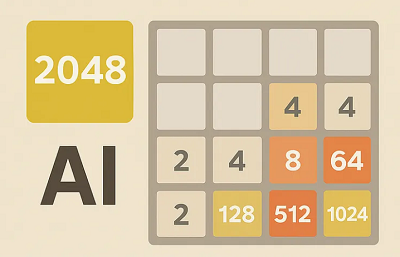

**Финальный проект по курсу**  
*"Data Science: машинное обучение и нейронные сети. Профессиональный уровень"*

**Автор:** Dziyana Lysak  
**Дата:** Апрель 2026

---

##  Цель проекта

Обучить нейросеть играть в головоломку `2048` с использованием `обучения с подкреплением (Reinforcement Learning)` и развернуть обученную модель в `Telegram-боте` для интерактивной демонстрации.

### Что такое 2048?
`2048` — это игра на поле `4×4`, где нужно соединять одинаковые плитки, чтобы получить плитку с числом `2048`. 

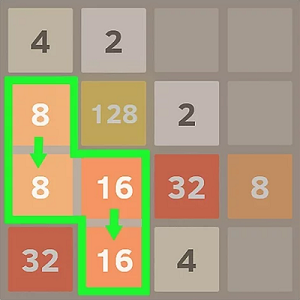

Несмотря на простые правила, игра требует стратегического мышления и планирования на несколько ходов вперёд.

### Почему именно `2048` — идеальный полигон для изучения RL:

- ✅ `Чёткая система наград` — очки начисляются за каждое слияние плиток
- ✅ `Полностью наблюдаемое состояние` — поле `4×4` всегда видно целиком
- ✅ `Дискретные действия` — конечное, счётное количество вариантов, всего `4 направления` (⬆️⬅️➡️⬇️)
- ✅ `Успех зависит от последовательности решений` — нельзя выиграть одним ходом

При этом игра содержит элемент `случайности` (новая плитка `2` или `4` в случайном месте), что делает невозможным создание гарантированно выигрышной стратегии. <br>
Агент должен научиться принимать решения в условиях неопределённости — именно для таких задач и предназначено `обучение с подкреплением`. 

*Взаимодействие агента со средой: состояние → действие → награда.*

---

##  Задачи проекта

Для достижения цели были поставлены следующие `задачи`:


### 1️⃣ Выбор алгоритма и среды

- Использовать готовую среду `gymnasium-2048` (поле `4×4`, стандартные правила)
- Применить алгоритм `PPO` (Proximal Policy Optimization) из библиотеки `stable-baselines3`
- В качестве нейросети — `MlpPolicy` (многослойный перцептрон)


### 2️⃣ Обучение модели

- Обучить `базовую версию` на `1 000 000` шагов
- Дообучить модель до `2 000 000` шагов
- Дообучить модель до `3 000 000` шагов
- Сохранить `все три версии` для сравнения прогресса


### 3️⃣ Тестирование и анализ

- Провести `сравнительное тестирование` всех трёх версий
- Зафиксировать `средний счёт`, `максимальную плитку`, `количество ходов`
- Проанализировать `прогресс обучения` на разных этапах


### 4️⃣ Разработка Telegram-бота

- Создать `интерактивного бота` с кнопками управления
- Реализовать `два режима`:
  - 🎮 Одиночная игра (человек против игры)
  - 🤖 Игра против ИИ (с выбором уровня сложности)
- Добавить `три уровня сложности`, соответствующие этапам обучения:
  - 🟢 `Новичок` (1M шагов)
  - 🟡 `Любитель` (2M шагов)
  - 🔴 `Профи` (3M шагов)
- Реализовать `запись игры ИИ в GIF` для наглядной демонстрации


### 5️⃣ Деплой (дополнительно)

- Подготовить `Dockerfile` и `requirements.txt`
- Развернуть бота на облачной платформе (в процессе)

---

##  Алгоритм и среда

###  PPO (Proximal Policy Optimization)

Для обучения был выбран алгоритм `PPO` — один из самых стабильных и популярных методов `обучения с подкреплением`.

`PPO` относится к семейству `Actor-Critic`:

🎭 **Actor** - Выбирает действие (куда двигать плитки) <br>
👁️ **Critic** - Оценивает состояние, насколько хорош текущий момент <br>
`Вместе они улучшают стратегию`

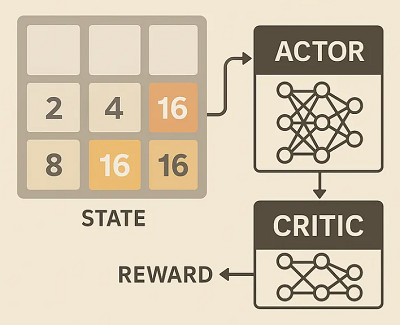

**Преимущества PPO:**
- ✅ Стабильное обучение без резких скачков
- ✅ Хорошо работает "из коробки"
- ✅ Не требует тонкой настройки гиперпараметров


###  Среда: gymnasium-2048

Использовалась готовая среда `gymnasium-2048`, реализующая стандартные правила игры:

- Поле `4×4`
- `4 действия`: ⬆️ вверх, ⬇️ вниз, ⬅️ влево, ➡️ вправо
- Награда: сумма значений `слившихся` плиток за ход

In [ ]:
import gymnasium as gym

env = gym.make("gymnasium_2048:gymnasium_2048/TwentyFortyEight-v0")

###  Оборачивание наблюдений

Среда возвращает состояние в виде матрицы `4×4×16` (one-hot encoding).  
Для подачи в нейросеть `MlpPolicy` наблюдение нужно `выпрямить` в вектор из `256` чисел:

In [ ]:
class FlattenObservation(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        from gymnasium import spaces
        self.observation_space = spaces.Box(
            low=0, high=1, shape=(256,), dtype=np.float32
        )

    def observation(self, obs):
        return obs.flatten()

env = FlattenObservation(env)

###  Создание модели PPO

Модель создавалась с использованием библиотеки `stable-baselines3`:

In [ ]:
from stable_baselines3 import PPO

model = PPO(
    "MlpPolicy",          # тип нейросети
    env,                  # среда
    verbose=1,            # показывать прогресс
    device="cuda",        # обучение на GPU
    n_steps=2048,         # шагов на сбор данных
    batch_size=64,        # размер батча
    learning_rate=0.00025 # скорость обучения
)

###  Запуск обучения

Обучение запускалось командой:

In [ ]:
model.learn(total_timesteps=1_000_000)
model.save("2048_ai")

###  Дообучение

Для получения версий `2M` и `3M` шагов использовалось дообучение:

In [ ]:
model = PPO.load("2048_ai", env=env)
model.learn(total_timesteps=1_000_000)
model.save("2048_ai_2M")

Таким образом были получены `три версии` модели:
- 🟢 `2048_ai_1M` — 1 000 000 шагов
- 🟡 `2048_ai_2M` — 2 000 000 шагов
- 🔴 `2048_ai_3M` — 3 000 000 шагов

---

##  Обучение модели

Обучение проводилось на компьютере с видеокартой `NVIDIA RTX 3060`.  
Было выполнено `три этапа` обучения с сохранением промежуточных версий модели.

### 🟢 Этап 1: Базовая модель (1 000 000 шагов)

Первичное обучение с нуля в течение `1 000 000` шагов.  
Время обучения: `~ 1-1,5 часа`.

**Параметры:**
- Алгоритм: `PPO`
- Политика: `MlpPolicy`
- Устройство: `CUDA` (GPU)

In [ ]:
model = PPO("MlpPolicy", env, verbose=1, device="cuda")
model.learn(total_timesteps=1_000_000)
model.save("2048_ai_1M")

### 🟡 Этап 2: Дообучение до 2 000 000 шагов

Загрузка сохранённой модели и дообучение ещё на `1 000 000` шагов.  
Время обучения: `~ 1-1,5 часа`.

In [ ]:
model = PPO.load("2048_ai_1M", env=env)
model.learn(total_timesteps=1_000_000)
model.save("2048_ai_2M")

### 🔴 Этап 3: Дообучение до 3 000 000 шагов

Загрузка модели `2M` и дообучение ещё на `1 000 000` шагов.  
Время обучения: `~ 1-1,5 часа`.

**Итог:** получены `три версии` модели, соответствующие разным этапам обучения.

In [ ]:
model = PPO.load("2048_ai_2M", env=env)
model.learn(total_timesteps=1_000_000)
model.save("2048_ai_3M")

### ✅ Итоги обучения

В результате трёх этапов были получены версии модели:

- 🟢 `2048_ai_1M.zip` — 1 000 000 шагов
- 🟡 `2048_ai_2M.zip` — 2 000 000 шагов
- 🔴 `2048_ai_3M.zip` — 3 000 000 шагов

Каждая следующая версия обучалась на основе предыдущей, `сохраняя накопленный опыт`.

---

##  Тестирование моделей

Чтобы объективно сравнить `три версии` модели, было проведено тестирование в одинаковых условиях.

**Параметры тестирования:**
- Количество партий для каждой модели: `5`
- Лимит ходов на партию: `1000`
- Режим: `deterministic` (без случайных действий)

Цель — проверить, насколько `увеличилась сила игры` с ростом количества шагов обучения.

In [ ]:
def test_model(model_path, games=5, max_steps=1000):
    model = PPO.load(model_path)
    scores = []
    
    for i in range(games):
        env = gym.make("gymnasium_2048:gymnasium_2048/TwentyFortyEight-v0")
        env = FlattenObservation(env)
        obs, _ = env.reset()
        done = False
        total_reward = 0
        step = 0
        
        while not done and step < max_steps:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
            step += 1
        
        scores.append(int(total_reward))
        env.close()
    
    return scores

###  Результаты тестирования

Тестирование показало `чёткий прогресс` с увеличением шагов обучения:

**🟢 Новичок (1M шагов)**
- Средний счёт: `~550` очков
- Максимальный счёт: `~1200` очков

**🟡 Любитель (2M шагов)**
- Средний счёт: `~700` очков
- Максимальный счёт: `~1300` очков

**🔴 Профи (3M шагов)**
- Средний счёт: `~980` очков
- Максимальный счёт: `~1600` очков

###  Анализ прогресса

Сравнение средних результатов:

- `1M → 2M`: прирост `~28%`
- `1M → 3M`: прирост `~78%`

**Выводы:**
- ✅ Модель `стабильно улучшается` с каждым этапом обучения
- ✅ Версия `Профи` показывает наилучшие результаты как по среднему, так и по максимальному счёту
- ✅ `Любитель` занимает промежуточное положение — уже лучше новичка, но ещё не так стабилен как профи

### 🔍 Особенности поведения

Интересные наблюдения во время тестирования:

- Модели `1M` и `2M` часто упирались в лимит `1000` ходов, но не набирали высокий счёт — они научились `выживать`, избегая проигрыша
- Модель `3M` показала `более агрессивную` стратегию — иногда завершала игру досрочно, но с `высоким счётом`
- Разброс результатов уменьшается с обучением — `Профи` играет стабильнее, чем `Новичок`

---

##  Telegram-бот

Для демонстрации работы обученных моделей был разработан `Telegram-бот`, позволяющий любому пользователю сыграть против ИИ или просто попрактиковаться в одиночной игре.

###  Доступ к боту

Бот доступен в Telegram: **[@my2048_ai_bot](https://t.me/my2048_ai_bot)**

Для запуска достаточно написать команду `/start`.

###  Возможности бота

- 🎯 **Одиночная игра** — классическая 2048 без соперника
- 🤖 **Игра против ИИ** — дуэль с нейросетью
- 🎚️ **Три уровня сложности** — `Новичок`, `Любитель`, `Профи`
- 📹 **Запись игры ИИ в GIF** — можно посмотреть, как думает машина
- 📖 **Встроенные правила** — подсказки по игре

### 📱 Главное меню

При запуске бота командой `/start` пользователь видит приветственное сообщение и главное меню с тремя кнопками.


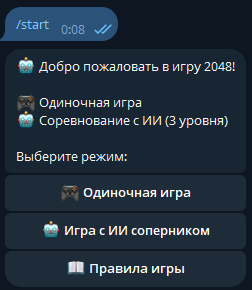

###  Выбор уровня сложности

При выборе режима "Игра с ИИ соперником" открывается меню выбора уровня:

- 🟢 `Новичок` — 1 млн шагов обучения
- 🟡 `Любитель` — 2 млн шагов обучения
- 🔴 `Профи` — 3 млн шагов обучения

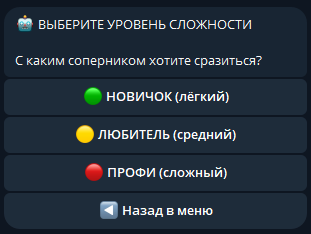

###  Игра ИИ

После выбора уровня ИИ начинает играть свою партию:

- Бот показывает `прогресс` выполнения
- ИИ проживает партию в реальном времени
- По окончании отправляется `GIF` с записью всей игры

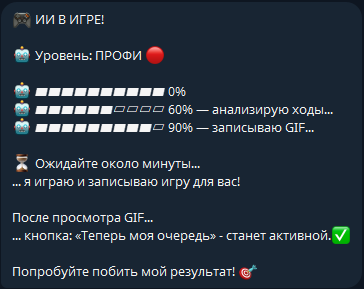

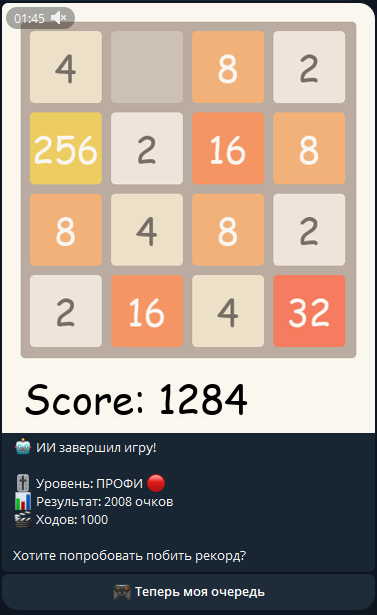

###  Игра пользователя

После завершения партии ИИ пользователь может сыграть свою:

- Напоминается `результат ИИ` и цель — побить его
- Управление: кнопки `⬆️ ⬅️ ➡️ ⬇️`
- Отображается текущий `счёт` и количество `ходов`

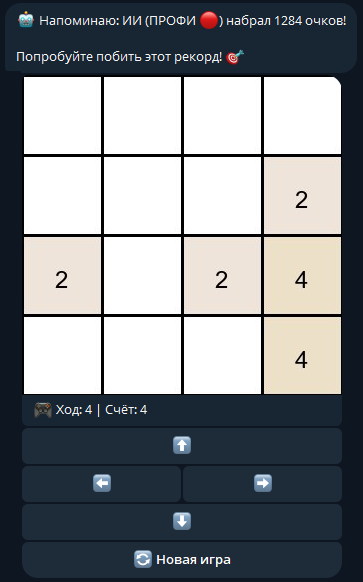


###  Объявление победителя

В конце игры (или по кнопке `"Новая игра"`) выводится итоговое сравнение:

- Результат ИИ
- Результат пользователя
- Объявление `победителя`

**Победа ИИ**

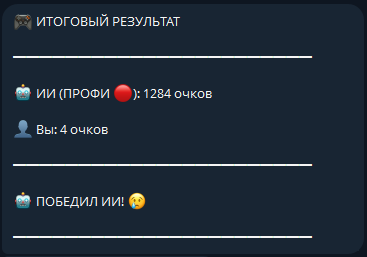

**Так выглядит, если победа пользователя**

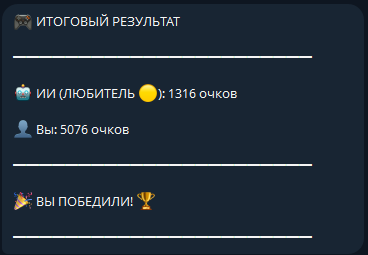

###  Правила игры

В боте есть встроенный раздел с правилами:

- Описание механики игры
- Пример слияния плиток
- Советы по стратегии

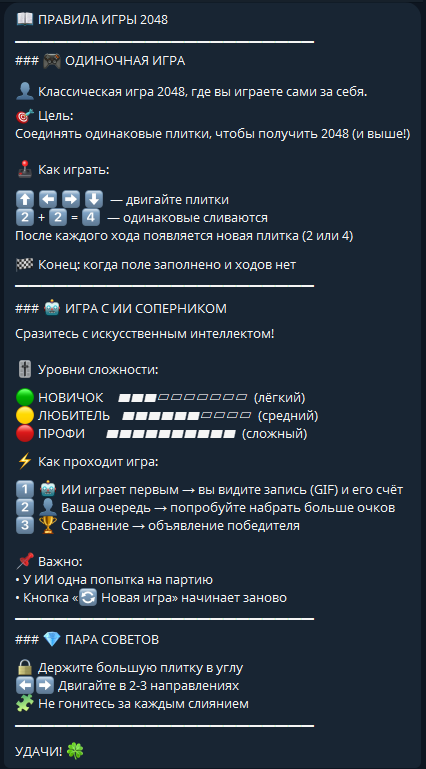

### ⚙️ Технические детали

- Библиотека: `python-telegram-bot`
- Управление: `InlineKeyboardMarkup` (кнопки под сообщениями)
- Визуализация: `PIL` (отрисовка поля), `imageio` (создание GIF)
- Модели: загружаются через `stable_baselines3`

---

## 🎬 Демонстрация работы

[Смотреть видео на Google Диске](https://drive.google.com/file/d/1Jd2_KnGnBrWoFMni89TwLzSb7hxCEVmX/view?usp=sharing)


---

##  Выводы

### ✅ Что удалось

-  Успешно обучен `RL-агент` для игры в `2048` с использованием алгоритма `PPO`
-  Проведено `трёхэтапное обучение` с сохранением версий: `1M`, `2M`, `3M` шагов
-  Выполнено `сравнительное тестирование` всех версий — подтверждён прогресс с ростом шагов
-  Разработан `Telegram-бот` с интерактивным интерфейсом и тремя уровнями сложности
-  Реализована `запись игры ИИ в GIF` для наглядной демонстрации
-  Подготовлена `Docker-конфигурация` для деплоя на облачные платформы

###  Прогресс обучения

- 🟢 `Новичок` (1M шагов): средний счёт `~550`, максимум `~1200`
- 🟡 `Любитель` (2M шагов): средний счёт `~700`, максимум `~1300`
- 🔴 `Профи` (3M шагов): средний счёт `~980`, максимум `~1600`

**Прирост от 1M к 3M:** `+78%` по среднему счёту.

###  Встреченные сложности

**Деплой на Render (неудачная попытка)**
- Планировалось развернуть бота на бесплатном тарифе платформы `Render`
- Однако `gymnasium-2048` требует `pygame`, который не установился в облачном окружении из-за отсутствия системных библиотек `SDL`
- Дополнительно возник `конфликт версий NumPy` — на Render устанавливалась версия `2.x`, несовместимая с сохранённой моделью
- После нескольких попыток исправления через `Dockerfile` было решено отложить деплой и сосредоточиться на локальной демонстрации

**Несовместимость версий NumPy**
- Модель сохранялась локально с `NumPy 1.x`, а в некоторых окружениях устанавливалась `NumPy 2.x`
- При загрузке модели возникала ошибка `ModuleNotFoundError: No module named 'numpy._core'`
- **Решение:** зафиксирована версия `numpy==2.4.4` и обновлён `stable-baselines3` до версии, корректно работающей с новым NumPy

**Git — случайное удаление файлов**
- При очистке staged-изменений командой `git restore` были случайно удалены локальные файлы `bot.py` и `train.py`, так как они не были закоммичены
- Файлы удалось восстановить через `Local History` в PyCharm
- **Вывод:** всегда делать `commit` перед опасными операциями с Git

**Git — случайное удаление файлов**
- На ранних этапах модель уходила в стратегию `бесконечного выживания` — избегала проигрыша, но не набирала очки
- **Решение:** ограничение в `1000` ходов на партию и дообучение модели

###  Возможные улучшения

- `Дообучить` модель до `5-10 млн` шагов для достижения плитки `2048`
- Заменить обычную нейросеть на `свёрточную` — это позволит модели учитывать пространственные связи между плитками (например, что большие значения лучше держать в углу)
- Научить модель `думать наперёд` — оценивать не только немедленную выгоду, но и последствия хода через несколько шагов
- Развернуть бота на `постоянном хостинге` (Hugging Face Spaces или VPS)
- Добавить `таблицу лидеров` и сохранение рекордов пользователей

###  Итог

Проект показал, что `обучение с подкреплением` — мощный, но требовательный инструмент. Даже относительно простая игра `2048` потребовала трёх этапов обучения и тщательной отладки.

Главный результат: `нейросеть действительно научилась играть`, а её прогресс наглядно виден при сравнении версий `1M → 2M → 3M` шагов.

Разработанный `Telegram-бот` делает проект `интерактивным` и позволяет любому желающему проверить свои силы в дуэли с искусственным интеллектом.